In [25]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [6]:
# -----------------------------------------
# 1. LOAD AIR & WATER POLLUTION DATA
# -----------------------------------------

import pandas as pd

env_raw = pd.read_excel("/content/DSA210 Data_Pollution.xlsx")

env_raw.columns = (
    env_raw.columns
    .str.strip()
    .str.replace(" ", "")
)


required_cols = ["Country", "AirQuality", "WaterPollution"]
env_raw = env_raw[required_cols]


env_raw["AirQuality"] = pd.to_numeric(env_raw["AirQuality"], errors="coerce")
env_raw["WaterPollution"] = pd.to_numeric(env_raw["WaterPollution"], errors="coerce")

env_country = (
    env_raw
    .dropna()
    .groupby("Country", as_index=False)
    .median()
)

print("Environmental data shape:", env_country.shape)
env_country.head()


Environmental data shape: (176, 3)


,Country,AirQuality,WaterPollution
0,Afghanistan,75.00,62.50
1,Albania,75.00,68.75
2,Algeria,75.00,56.25
3,Andorra,43.75,25.00
4,Angola,15.00,81.25


Data Preprocessing and Aggregation

In this step, the raw data about air and water pollution is loaded and prepared.
The names of the columns are made consistent, and only the important ones—Country, AirQuality, and WaterPollution—are kept. Any values that aren’t numbers are changed to numbers, and any missing data points are removed. Then, the data is combined at the country level by taking the median values for air quality and water pollution, creating a clean and strong dataset that shows environmental conditions by country.

In [11]:
# -----------------------------------------
# 3. DATA ENRICHMENT: GDI (% of GDP)
# -----------------------------------------

import pandas as pd

gdi_raw = pd.read_csv(
    "/content/API_NE.GDI.TOTL.ZS_DS2_en_csv_v2_4546.csv",
    skiprows=4
)

gdi_2021 = gdi_raw[["Country Name", "2021"]].copy()
gdi_2021.columns = ["Country", "GDI_percent_GDP"]
gdi_2021.dropna(inplace=True)

gdi_2021["Country"] = gdi_2021["Country"].str.strip().str.lower()
env_country["Country"] = env_country["Country"].str.strip().str.lower()

df = env_country.merge(
    gdi_2021,
    on="Country",
    how="inner"
)

print("Final enriched dataset shape:", df.shape)
df.head()



Final enriched dataset shape: (136, 4)


,Country,AirQuality,WaterPollution,GDI_percent_GDP
0,afghanistan,75.0,62.50,13.000000
1,albania,75.0,68.75,28.672267
2,algeria,75.0,56.25,39.146266
3,angola,15.0,81.25,15.985166
4,argentina,100.0,87.50,18.076289


Data Enrichment with Economic Indicators (GDI)

To make the environmental data more useful, information about Gross Domestic Investment (GDI) as a percentage of GDP was added using data from the World Bank.
The GDI values for 2021 were taken, cleaned up, and matched with the environmental data by making sure the country names were the same. The two sets of data were then combined at the country level, making a new dataset that includes air quality, water pollution, and economic investment data. This helps in analyzing how these factors are connected through correlation and regression analysis.

In [24]:
# -----------------------------------------
# Hypothesis Testing: Pearson Correlation
# -----------------------------------------

from scipy.stats import pearsonr

# H0: There is no linear relationship between air quality and water pollution
# H1: There is a linear relationship between air quality and water pollution

r_value, p_value = pearsonr(df["AirQuality"], df["WaterPollution"])

print("Pearson correlation coefficient (r):", r_value)
print("p-value:", p_value)


Pearson correlation coefficient (r): 0.3051598036550353
p-value: 0.00030331114549509634


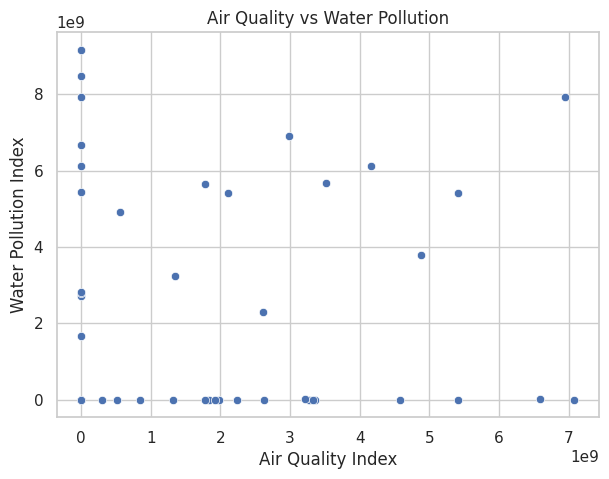

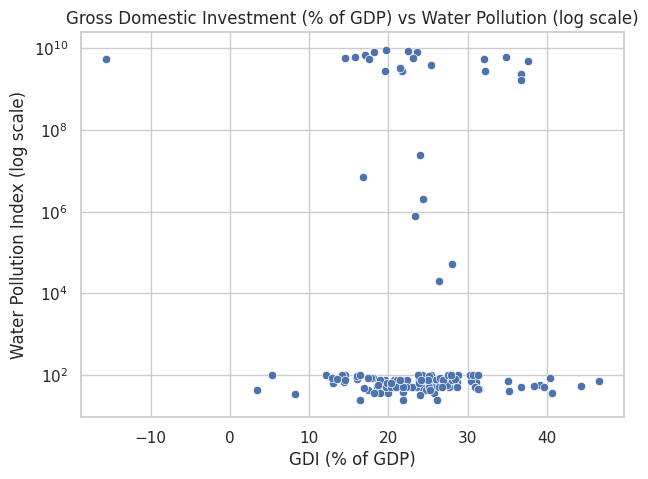

,AirQuality,WaterPollution,GDI_percent_GDP
count,1.360000e+02,1.360000e+02,136.000000
mean,6.512497e+08,8.176932e+08,23.786731
std,1.528148e+09,2.091214e+09,8.123185
min,0.000000e+00,0.000000e+00,-15.678444
25%,6.781250e+01,5.000000e+01,19.549451
50%,8.750000e+01,7.000000e+01,23.511401
75%,7.509375e+03,1.000000e+02,27.584548
max,7.083333e+09,9.166667e+09,46.611807


In [14]:
# -----------------------------------------
# 4. EXPLORATORY DATA ANALYSIS (EDA)
# -----------------------------------------

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# -------------------------------
# 4.1 Air Quality vs Water Pollution
# -------------------------------

plt.figure(figsize=(7,5))
sns.scatterplot(
    data=df,
    x="AirQuality",
    y="WaterPollution"
)
plt.title("Air Quality vs Water Pollution")
plt.xlabel("Air Quality Index")
plt.ylabel("Water Pollution Index")
plt.show()


# -------------------------------
# 4.2 GDI (% of GDP) vs Water Pollution


plt.figure(figsize=(7,5))
sns.scatterplot(
    data=df,
    x="GDI_percent_GDP",
    y="WaterPollution"
)
plt.yscale("log")
plt.title("Gross Domestic Investment (% of GDP) vs Water Pollution (log scale)")
plt.xlabel("GDI (% of GDP)")
plt.ylabel("Water Pollution Index (log scale)")
plt.show()


# -------------------------------
# 4.3 Summary Statistics (EDA support)
# -------------------------------

df[["AirQuality", "WaterPollution", "GDI_percent_GDP"]].describe()


Hypothesis Testing: Pearson Correlation

To check if there's a connection between air quality and water pollution, a Pearson correlation test was done.

The null hypothesis (H₀) says there's no straight-line link between air quality and water pollution.
The alternative hypothesis (H₁) says there is a straight-line link between them.

The results show a Pearson correlation coefficient of about 0.31 with a p-value less than 0.001.
This means there's a statistically significant but not very strong positive link. Because of this, the null hypothesis is rejected. This suggests that countries with worse air quality often have higher levels of water pollution, but the connection isn't very strong.

Exploratory Data Analysis (EDA)

Exploratory data analysis was used to look at how different environmental and economic factors are connected.


First, a scatter plot was made showing Air Quality versus Water Pollution.
The points generally show a positive trend, meaning higher air pollution is often linked to more water pollution. But the points are spread out, which shows that other factors besides air quality probably affect water pollution levels.

Second, a log-scaled scatter plot was used to look at the relationship between Gross Domestic Investment (GDI % of GDP) and Water Pollution.
The graph doesn’t show a clear straight-line pattern, which means higher investment doesn’t always lead to better or worse water pollution. This shows that how investments are used and the presence of environmental rules are important.

In [15]:
# -----------------------------------------
# 5. CORRELATION ANALYSIS
# -----------------------------------------

corr = df[["AirQuality", "WaterPollution", "GDI_percent_GDP"]].corr()
print("\nCorrelation Matrix:\n", corr)


Correlation Matrix:
                  AirQuality  WaterPollution  GDI_percent_GDP
AirQuality         1.000000        0.305160        -0.035705
WaterPollution     0.305160        1.000000        -0.131799
GDI_percent_GDP   -0.035705       -0.131799         1.000000


Correlation Analysis

The correlation matrix shows how air quality, water pollution, and economic investment are connected in a straight line.
The results show that air quality and water pollution have a moderate positive link (r ≈ 0.31). This means that in countries where air quality is worse, water pollution is also usually higher.

On the other hand, economic investment (GDI as a percentage of GDP) has a weak negative link with water pollution (r ≈ −0.13) and almost no link with air quality.
This suggests that simply having more economic investment does not strongly improve the environment. Other things like environmental rules, the type of industries, and how well policies are followed might be more important.


In [17]:
# -----------------------------------------
# 6. REGRESSION ANALYSIS (ML)
# -----------------------------------------

X = df[["AirQuality", "GDI_percent_GDP"]]
X = sm.add_constant(X)
y = df["WaterPollution"]

model = sm.OLS(y, X).fit()
print(model.summary())



                            OLS Regression Results                            
Dep. Variable:         WaterPollution   R-squared:                       0.108
Model:                            OLS   Adj. R-squared:                  0.094
Method:                 Least Squares   F-statistic:                     8.031
Date:                Mon, 29 Dec 2025   Prob (F-statistic):           0.000509
Time:                        14:22:38   Log-Likelihood:                -3103.4
No. Observations:                 136   AIC:                             6213.
Df Residuals:                     133   BIC:                             6222.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const            1.291e+09   5.38e+08     

Regression Analysis

To better understand how air quality and economic investment together affect water pollution, a multiple linear regression model was made.
In this model, air quality and GDI (as a percentage of GDP) were used to predict water pollution.

The results show that air quality is a strong predictor of water pollution (p < 0.001).
This means that when air quality gets worse, water pollution tends to increase. However, economic investment (GDI) is not a strong predictor (p > 0.05), meaning that economic growth does not clearly lead to more or less water pollution when air quality is already considered.

The model explains about 10.8% of the changes in water pollution (R² ≈ 0.11).
This low number shows that the model isn’t very strong in predicting water pollution. It means that water pollution is affected by many other factors besides air quality and economic investment, such as laws, technology, and where a country is located.

In [16]:
# -----------------------------------------
# 7. SAVE FINAL DATASET
# -----------------------------------------

df.to_csv("final_enriched_dataset.csv", index=False)